> **Repo:** `cemepi-ctf-intel-fiscal` / `projects/litigancia` · **Article:** EPED 2026  
> Figures export to `../figures/` via `show_and_save()`.


# Análise Estrutural e Econômica do Acervo de Processos (Fazenda Pública)

**Material Suplementar** Este *notebook* documenta a metodologia de extração, limpeza, auditoria de qualidade e análise exploratória de dados (EDA) aplicada a um acervo de processos judiciais. 

### Metodologia Computacional
Para garantir a reprodutibilidade e lidar com *Big Data* em memória de forma eficiente, a arquitetura de processamento utiliza a biblioteca **Polars** (escrita em Rust). A abordagem de *Lazy Evaluation* (Avaliação Preguiçosa) permite que os filtros lexicais e cálculos de engenharia de *features* sejam aplicados diretamente no motor de busca sobre os arquivos Parquet subjacentes, sem sobrecarregar a memória RAM.

### Variáveis de Destaque
- **Recorte Amostral:** Processos onde o Estado de São Paulo atua no polo ativo ou passivo.
- **Métrica Financeira:** Todas as exposições financeiras utilizam o valor monetário corrigido pela série histórica do IPCA/BCB até a data presente, garantindo comparabilidade atemporal e controle da inflação no período longitudinal analisado.

In [38]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import warnings
from pathlib import Path

from config.paths import REPO_ROOT, SILVER_FACE_CLEAN, SILVER_PROCESSOS

warnings.filterwarnings('ignore')

# Configuração visual padronizada para publicações acadêmicas (Paper-ready)
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

ARTICLE_ROOT = REPO_ROOT / "projects/litigancia/notebooks/articles/eped-2026-analise-execucoes-fiscais"
SILVER_FACE_TABLE = str(SILVER_FACE_CLEAN)
FIGURES_DIR = ARTICLE_ROOT / "figures"
ARTIFACTS_DIR = ARTICLE_ROOT / "artifacts"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

_fig_counter = 0

def show_and_save(stem: str) -> Path:
    """Save current figure to ../figures/ then display."""
    global _fig_counter
    _fig_counter += 1
    path = FIGURES_DIR / f"{_fig_counter:02d}_{stem}.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    return path

print("Ambiente computacional inicializado.")
print(f"Silver face: {SILVER_FACE_TABLE}")
print(f"Figures dir: {FIGURES_DIR}")


Ambiente computacional inicializado.
Silver face: /Volumes/Meedi_Etore_HD1/CEMEPI/Coletas/gilson/silver_layer/face_processos_clean_delta
Figures dir: /Users/etorebraga/Code/habitual-tax-debtor-research/notebooks/articles/eped-2026-analise-execucoes-fiscais/figures


## 1. Processamento e Engenharia de Features (Polars Backend)
A fase de ingestão aplica a filtragem do polo ativo (Regex normalizado) para extrair estritamente casos vinculados ao "Estado de São Paulo". As métricas de *Survival Analysis* (tempo até a sentença) são calculadas em nível computacional antes da materialização em memória RAM.

In [39]:
print("Iniciando varredura otimizada (Lazy Evaluation)...")

# Recorte canônico: round2 ICMS (coleta_assunto_icms) ∩ FESP ∩ allowlist de assuntos.
# Não usamos keyword "Importação" — ela captura PIS/COFINS/II (federais) e Taxa de Licença (municipal)
# de outras coletas no lake.
ICMS_ASSUNTOS = [
    "ICMS/ Imposto sobre Circulação de Mercadorias",
    "ICMS/Importação",
    "ICMS / Incidência Sobre o Ativo Fixo",
]

FESP_AUTOR_PATTERN = (
    r"fazenda do estado|fazenda estadual|\bfesp\b|"
    r"estado de s[aã]o paulo|faz\.?\s*estad|fda estado"
)

round2_cds = (
    pl.scan_delta(str(SILVER_PROCESSOS))
    .filter(pl.col("source_bronze_path").cast(pl.Utf8).str.contains("coleta_assunto_icms"))
    .select("cd_processo")
    .unique()
)

lazy_filtered = (
    pl.scan_delta(SILVER_FACE_TABLE)
    .join(round2_cds, on="cd_processo", how="inner")
    .filter(pl.col("assunto").is_in(ICMS_ASSUNTOS))
    .filter(
        pl.col("autores")
        .cast(pl.Utf8)
        .str.to_lowercase()
        .str.contains(FESP_AUTOR_PATTERN)
        .fill_null(False)
    )
)


# 3. Engenharia de Features Temporal e Validação
lazy_engineered = lazy_filtered.with_columns([
    # Tempo em dias e meses (Apenas para dados consistentes onde sentença > distribuição)
    pl.when(pl.col("data_sentenca_clean").cast(pl.Date) >= pl.col("distribuicao_data").cast(pl.Date))
      .then((pl.col("data_sentenca_clean").cast(pl.Date) - pl.col("distribuicao_data").cast(pl.Date)).dt.total_days())
      .otherwise(None).alias("tempo_ate_sentenca_dias"),
      
    pl.when(pl.col("data_sentenca_clean").cast(pl.Date) >= pl.col("distribuicao_data").cast(pl.Date))
      .then((pl.col("data_sentenca_clean").cast(pl.Date) - pl.col("distribuicao_data").cast(pl.Date)).dt.total_days() / 30.44)
      .otherwise(None).alias("tempo_ate_sentenca_meses"),
      
    pl.col("distribuicao_data").dt.year().alias("ano_distribuicao")
])

# 4. Materialização (Executa a query e traz apenas o recorte para a RAM)
# A silver face é append-only; quando há re-scrape do mesmo cd_processo,
# mantemos a versão mais recente antes de materializar/exportar.
lazy_engineered = lazy_engineered.sort("ingested_at", descending=True).unique(
    subset=["cd_processo"],
    keep="first",
    maintain_order=True,
)

# A coluna `movimentações` costuma ser um payload grande (lista/dicts por processo),
# o que explode o uso de RAM no notebook. Ela não é usada nas análises do EDA.
if "movimentações" in lazy_engineered.columns:
    lazy_engineered = lazy_engineered.drop("movimentações")

df_pl = lazy_engineered.collect(engine="streaming")

# 5. Limpeza dos Dados: Consertando "Vara Única" e os "Setores"
df_pl = df_pl.with_columns([
    pl.col("vara").str.to_lowercase()
      .str.replace("setor das execuções fiscais", "setor de execuções fiscais")
      .str.to_titlecase()
      .alias("vara_limpa")
])

df_pl = df_pl.with_columns([
    pl.when(pl.col("vara_limpa").str.contains("Vara Única"))
      .then(pl.col("foro") + " - " + pl.col("vara_limpa"))
      .otherwise(pl.col("vara_limpa"))
      .alias("vara_limpa")
])

# Remove manualmente os erros crassos do cartório identificados na auditoria
processos_com_erro = [
    "1500152-68.2019.8.26.0014", # Mercantil Farmed (Erro de 654M)
    "1503946-34.2018.8.26.0014", # Loja de Sutiãs (Erro de 260M)
    "1505517-89.2022.8.26.0114", # Pessoa Física (Erro de 100M)
]
df_pl = df_pl.filter(~pl.col("numero").is_in(processos_com_erro))

total_processos = df_pl.height

print(f"Materialização concluída. Total de processos identificados (Amostra FESP): {total_processos:,}")

Iniciando varredura otimizada (Lazy Evaluation)...
Materialização concluída. Total de processos identificados (Amostra FESP): 292,920


## 2. Auditoria de Qualidade dos Dados (Data Sanity)
Em análises empíricas do Direito (Jurimetria), a qualidade do registro dos Tribunais é historicamente imperfeita. Esta seção documenta as métricas de completude, identificando não apenas valores formalmente nulos (`NaN`), mas também ruídos textuais sistemáticos gerados pela ausência de preenchimento nos sistemas dos tribunais (ex: *"NÃO HÁ REGISTRO"*).

Tabela 1: Taxa de Completude Informacional por Atributo Processual (Inventário Completo)


,Atributo,Sinal_Valido,Ausente_ou_Ruido,Completude (%)
11,advogados_autores,114989,177931,39.26
13,advogados_reus,117584,175336,40.14
25,valor_sm,268041,24879,91.51
24,valor_corrigido_atual,268041,24879,91.51
21,valor_limpo,268041,24879,91.51
29,tempo_ate_sentenca_meses,273223,19697,93.28
28,tempo_ate_sentenca_dias,273223,19697,93.28
8,valor,281000,11920,95.93
12,reus,288029,4891,98.33
23,tempo_tramitacao_meses,288231,4689,98.40


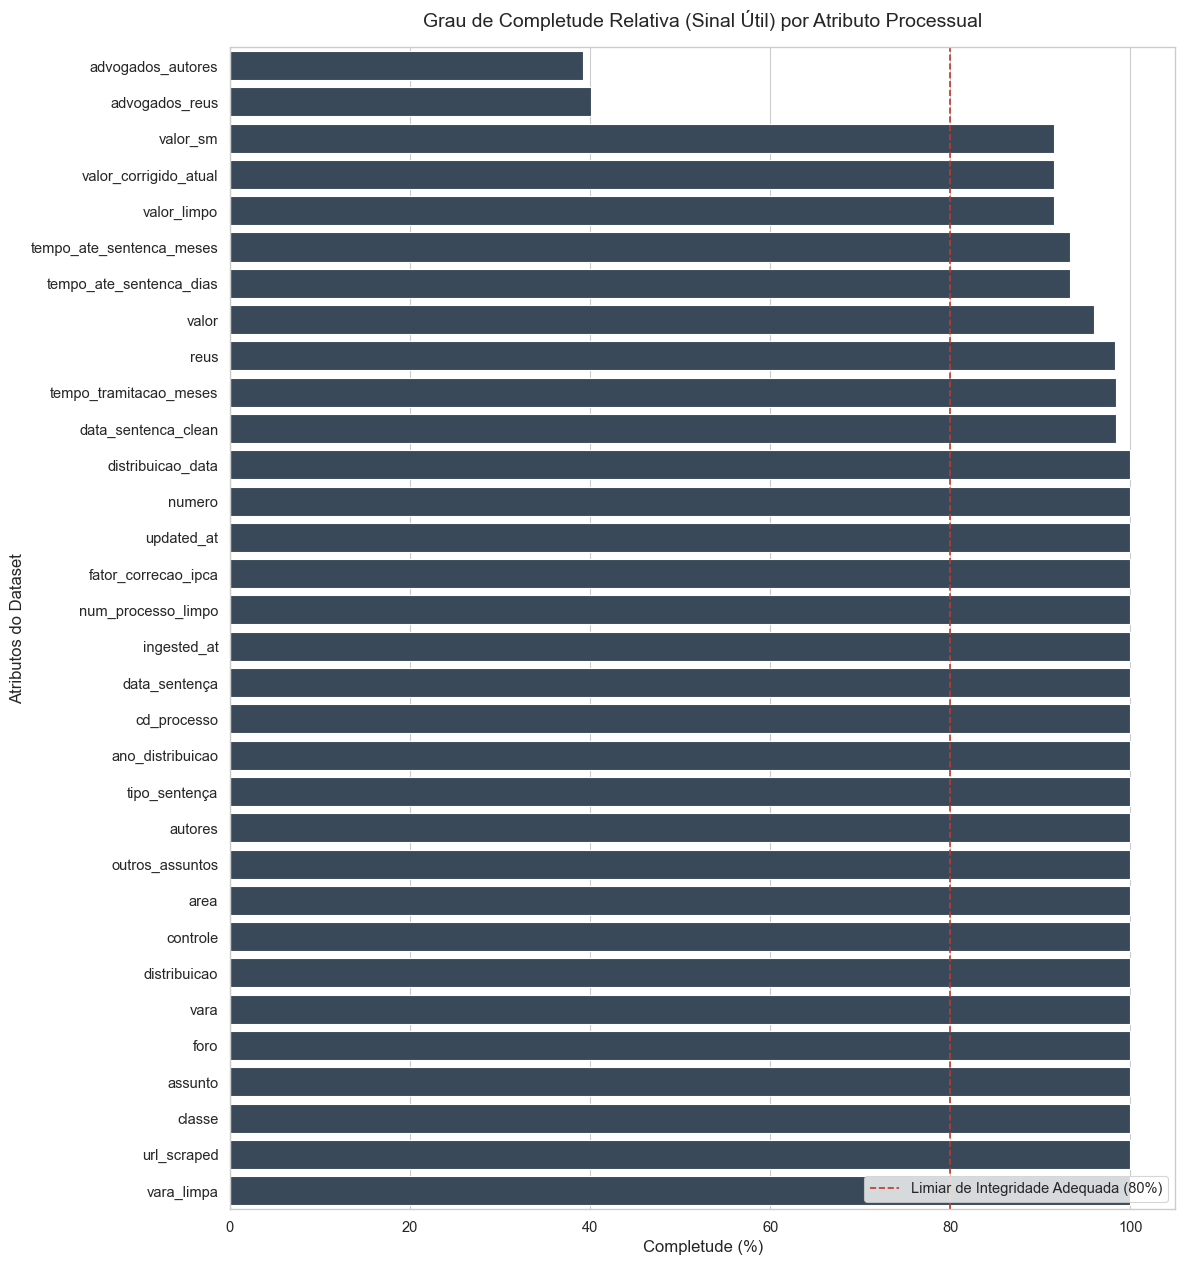

In [40]:
# Avaliação nativa em Polars para altíssima performance
dq_records = []
ruidos_conhecidos = ["NÃO HÁ REGISTRO", "nan", "null", ""]

for col in df_pl.columns:
    if df_pl.schema[col] == pl.String:
        # Conta Nulos Reais + Strings de Ruído
        ausentes = df_pl.filter(
            pl.col(col).is_null() | pl.col(col).str.strip_chars().is_in(ruidos_conhecidos)
        ).height
    else:
        ausentes = df_pl.filter(pl.col(col).is_null()).height
        
    completude = ((total_processos - ausentes) / total_processos) * 100
    
    dq_records.append({
        "Atributo": col,
        "Sinal_Valido": total_processos - ausentes,
        "Ausente_ou_Ruido": ausentes,
        "Completude (%)": completude
    })

# Convertendo o sumário para Pandas apenas para visualização e formatação
df_dq = pd.DataFrame(dq_records).sort_values(by="Completude (%)", ascending=True)

print("Tabela 1: Taxa de Completude Informacional por Atributo Processual (Inventário Completo)")
# Removido o .head(10) para exibir a tabela integralmente
display(df_dq.round(2))

# Ajuste dinâmico de altura: garante que os nomes das colunas não fiquem espremidos
altura_dinamica = max(8, len(df_dq) * 0.4)
plt.figure(figsize=(12, altura_dinamica))

# Removido o .head(12) para incluir todas as colunas no gráfico
sns.barplot(data=df_dq, y="Atributo", x="Completude (%)", color="#34495e")

plt.axvline(x=80, color="#c0392b", linestyle="--", label="Limiar de Integridade Adequada (80%)")
plt.title("Grau de Completude Relativa (Sinal Útil) por Atributo Processual", pad=15)
plt.xlabel("Completude (%)")
plt.ylabel("Atributos do Dataset")
plt.legend(loc="lower right")

# tight_layout garante que as margens se ajustem perfeitamente ao texto
plt.tight_layout()
show_and_save("evolucao_longitudinal")
plt.show()

### 2.1. Anomalias e Valores Extremos (Outliers)
A auditoria inclui a varredura por inconsistências lógicas de inserção manual pelos serventuários (viagens no tempo) e a constatação da distribuição estatística de valores.

A distribuição do valor em disputas fiscais não adere a uma curva de distribuição normal (Gaussiana), governando-se majoritariamente por uma **Lei de Potência (Power Law)**. Consequentemente, utilizamos o Método do Intervalo Interquartil (IQR) para delimitar matematicamente a fronteira dos *outliers* macroeconômicos.

In [41]:
print("="*60)
print("AUDITORIA DE INCONSISTÊNCIAS E LIMITES ESTATÍSTICOS")
print("="*60)

# 1. Inconsistências Lógicas Temporais
ano_atual = pd.Timestamp.now().year
datas_absurdas = df_pl.filter(
    (pl.col("distribuicao_data").dt.year() < 1950) | 
    (pl.col("distribuicao_data").dt.year() > ano_atual)
).height

sentencas_paradoxais = lazy_filtered.filter(
    pl.col("data_sentenca_clean").cast(pl.Date) < pl.col("distribuicao_data").cast(pl.Date)
).collect().height

print(f"Data de distribuição improvável (fora de 1950-{ano_atual}): {datas_absurdas:,} registros")
print(f"Paradoxo Temporal (Sentença proferida antes da distribuição): {sentencas_paradoxais:,} registros")

# 2. Definição do Limite Outlier para Valor da Causa (Corrigido)
# Removendo nulos para o cálculo do Quartil
valores_validos = df_pl.filter(pl.col("valor_corrigido_atual").is_not_null() & (pl.col("valor_corrigido_atual") > 0))
q1 = valores_validos.select(pl.col("valor_corrigido_atual").quantile(0.25)).item()
q3 = valores_validos.select(pl.col("valor_corrigido_atual").quantile(0.75)).item()
iqr = q3 - q1
limite_superior_valor = q3 + 1.5 * iqr

outliers_financeiros = valores_validos.filter(pl.col("valor_corrigido_atual") > limite_superior_valor).height
porcentagem_outliers = (outliers_financeiros / total_processos) * 100

print(f"\nLimiar superior pelo IQR (Valor Corrigido): R$ {limite_superior_valor:,.2f}")
print(f"Quantidade de Outliers Financeiros Extremos: {outliers_financeiros:,} ({porcentagem_outliers:.2f}% do acervo)")
print("="*60)

AUDITORIA DE INCONSISTÊNCIAS E LIMITES ESTATÍSTICOS
Data de distribuição improvável (fora de 1950-2026): 1 registros
Paradoxo Temporal (Sentença proferida antes da distribuição): 15,057 registros

Limiar superior pelo IQR (Valor Corrigido): R$ 190,827.72
Quantidade de Outliers Financeiros Extremos: 39,520 (13.49% do acervo)


### 2.2. Tratamento Contextual de Foros e Varas (Engenharia de Features)
Em bases de dados do Judiciário, nomenclaturas genéricas como "Vara Única" introduzem ruído analítico por perda de referência espacial. Adicionalmente, inconsistências lexicais (e.g., "Setor das Execuções" vs "Setor de Execuções") pulverizam artificialmente a contagem de processos. A rotina abaixo realiza a padronização textual e a agregação do Foro à Vara quando necessário.

In [42]:
# 1. Padroniza a string da vara (minúsculo, arruma os "setores" e garante o acento da vara única)
df_pl = df_pl.with_columns([
    pl.col("vara")
      .fill_null("Vara Não Informada") # Caso alguma linha venha vazia
      .str.to_lowercase()
      .str.replace_all("setor das execuções fiscais", "setor de execuções fiscais")
      .str.replace_all("vara unica", "vara única") # Garante que todas tenham acento
      .str.to_titlecase()
      .alias("vara_limpa_temp")
])

# 2. Concatenação Universal: Junta o Foro com a Vara limpa para TODAS as linhas
df_pl = df_pl.with_columns([
    (pl.col("foro").fill_null("Foro Não Informado") + " - " + pl.col("vara_limpa_temp"))
    .alias("vara_limpa")
]).drop("vara_limpa_temp") # Apaga a coluna temporária para manter o dataset limpo

# Mostra uma amostra de como ficou para você conferir:
print(df_pl.select(["foro", "vara", "vara_limpa"]).head(5))

shape: (5, 3)
┌──────────────────────┬─────────────────────────────────┬─────────────────────────────────┐
│ foro                 ┆ vara                            ┆ vara_limpa                      │
│ ---                  ┆ ---                             ┆ ---                             │
│ str                  ┆ str                             ┆ str                             │
╞══════════════════════╪═════════════════════════════════╪═════════════════════════════════╡
│ Foro 5 - Núcleo 4.0  ┆ Unidade 5 - Núcleo 4.0 Execuçõ… ┆ Foro 5 - Núcleo 4.0 - Unidade … │
│ Foro 12 - Núcleo 4.0 ┆ Unidade 12 - Núcleo 4.0 Execuç… ┆ Foro 12 - Núcleo 4.0 - Unidade… │
│ Foro 3 - Núcleo 4.0  ┆ Unidade 3 - Núcleo 4.0 Execuçõ… ┆ Foro 3 - Núcleo 4.0 - Unidade … │
│ Foro 3 - Núcleo 4.0  ┆ Unidade 3 - Núcleo 4.0 Execuçõ… ┆ Foro 3 - Núcleo 4.0 - Unidade … │
│ Foro 6 - Núcleo 4.0  ┆ Unidade 6 - Núcleo 4.0 Execuçõ… ┆ Foro 6 - Núcleo 4.0 - Unidade … │
└──────────────────────┴────────────────────────────────

## 3. Análise Exploratória e Resultados Jurimétricos (EDA)

*(Nota Metodológica: Todos os indicadores financeiros a seguir repousam sobre o atributo de controle temporal **`valor_corrigido_atual`**, contemplando a incidência do IPCA desde a data de distribuição até o tempo presente. Essa normalização é essencial para mitigar as distorções da inflação acumulada ao analisar portfólios distribuídos ao longo de décadas). Estes dados incluem massa falida e outros outliers. Portanto não deve ser levado como dado final.*

In [43]:
# Agregações hiper-rápidas no Polars
metricas_macro = df_pl.select([
    pl.col("valor_corrigido_atual").sum().alias("exposicao_total"),
    pl.col("valor_corrigido_atual").mean().alias("ticket_medio"),
    pl.col("data_sentenca_clean").is_not_null().mean().alias("taxa_resolucao")
]).to_dicts()[0]

exposicao_total = metricas_macro["exposicao_total"] or 0
ticket_medio = metricas_macro["ticket_medio"] or 0
taxa_resolucao = metricas_macro["taxa_resolucao"] * 100

print(f"Volume Analisado: {total_processos:,.0f} processos")
print(f"Exposição Financeira Agregada (IPCA Corrigido): R$ {exposicao_total:,.2f}")
print(f"Ticket Médio por Demanda (IPCA Corrigido): R$ {ticket_medio:,.2f}")
print(f"Taxa de Prevalência de Sentenças: {taxa_resolucao:.1f}%")

Volume Analisado: 292,920 processos
Exposição Financeira Agregada (IPCA Corrigido): R$ 4,520,291,740,258.37
Ticket Médio por Demanda (IPCA Corrigido): R$ 16,864,180.26
Taxa de Prevalência de Sentenças: 98.4%


### 3.1. Evolução Longitudinal da Distribuição Processual e Sentença
Comportamento de ajuizamento de novas ações na linha do tempo. Permite visualizar sazonalidades ou impactos de alterações legislativas.

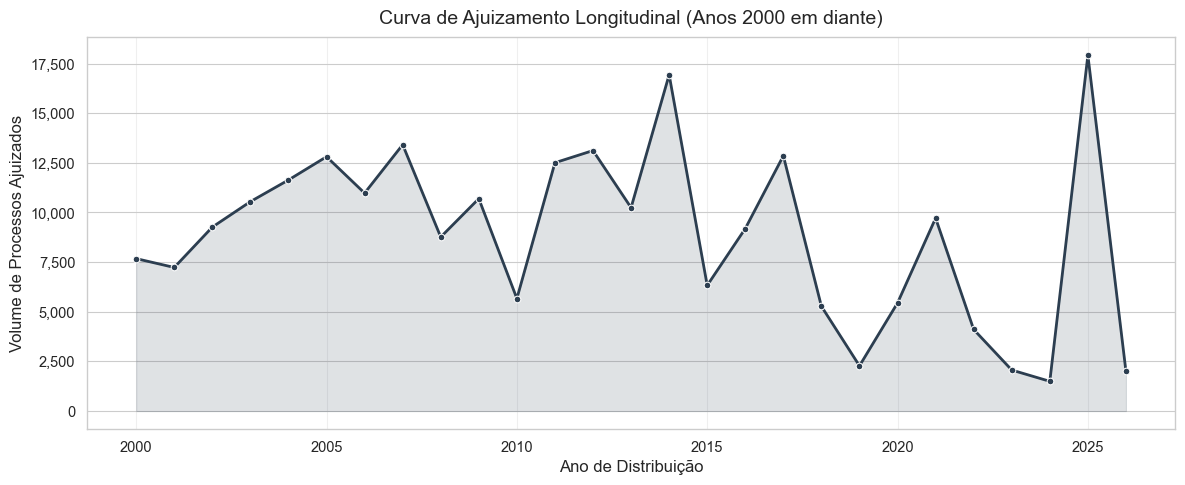

In [44]:
# Agrupamento no Polars, ordenação, e conversão pequena para Pandas
df_evolucao = df_pl.filter(
    (pl.col("ano_distribuicao") >= 2000) & (pl.col("ano_distribuicao") <= ano_atual)
).group_by("ano_distribuicao").len().sort("ano_distribuicao").to_pandas()

plt.figure(figsize=(12, 5))
ax = sns.lineplot(data=df_evolucao, x="ano_distribuicao", y="len", marker="o", color="#2c3e50", linewidth=2)

plt.title("Curva de Ajuizamento Longitudinal (Anos 2000 em diante)", pad=10)
plt.xlabel("Ano de Distribuição")
plt.ylabel("Volume de Processos Ajuizados")
plt.fill_between(df_evolucao["ano_distribuicao"], df_evolucao["len"], alpha=0.15, color="#2c3e50")

# Formatar eixo Y
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
show_and_save("volume_operacional")
plt.show()

### 3.1.2. Evolução Longitudinal de Resoluções (Produtividade)
Comportamento do volume de sentenças proferidas ao longo do tempo. Esta métrica, quando contrastada com a curva de ajuizamento, permite identificar gargalos ou ganhos de vazão do Poder Judiciário.

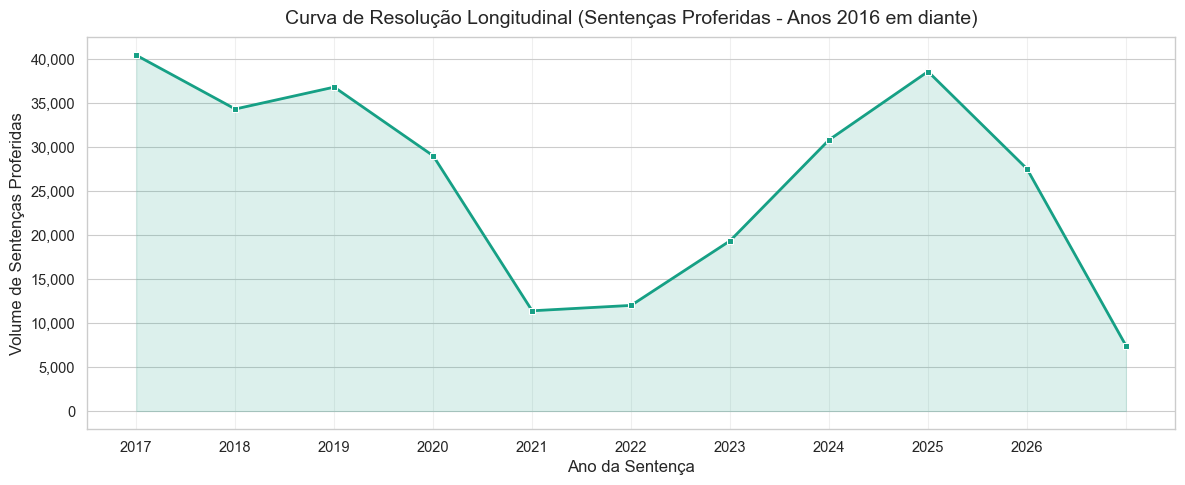

In [45]:
# 1. Extrair o Ano da Sentença diretamente no Polars (caso ainda não exista)
if "ano_sentenca" not in df_pl.columns:
    df_pl = df_pl.with_columns(
        pl.col("data_sentenca_clean").cast(pl.Date).dt.year().alias("ano_sentenca")
    )

# 2. Agrupamento no Polars, filtrando nulos e limitando o período temporal
df_evolucao_sentenca = df_pl.filter(
    (pl.col("ano_sentenca").is_not_null()) &
    (pl.col("ano_sentenca") >= 2016) & 
    (pl.col("ano_sentenca") <= ano_atual)
).group_by("ano_sentenca").len().sort("ano_sentenca").to_pandas()

# 3. Plotagem do Gráfico
plt.figure(figsize=(12, 5))
ax = sns.lineplot(
    data=df_evolucao_sentenca, 
    x="ano_sentenca", 
    y="len", 
    marker="s", # Usando 's' (square) para diferenciar do gráfico de distribuição
    color="#16a085", # Tom de verde/teal representando "resolução"
    linewidth=2
)

plt.title("Curva de Resolução Longitudinal (Sentenças Proferidas - Anos 2016 em diante)", pad=10)
plt.xlabel("Ano da Sentença")
plt.ylabel("Volume de Sentenças Proferidas")

# Preenchimento sob a curva para melhorar a visualização do volume
plt.fill_between(
    df_evolucao_sentenca["ano_sentenca"], 
    df_evolucao_sentenca["len"], 
    alpha=0.15, 
    color="#16a085"
)

# Formatar eixo Y para apresentar separador de milhares
ax.xaxis.set_major_locator(plt.MultipleLocator(1))
ax.xaxis.set_major_formatter(plt.FixedFormatter([str(i) for i in range(2016, ano_atual+1, 1)]))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
show_and_save("concentracao_foro_vara_volume")
plt.show()

### 3.1.3. Volume Operacional de Distribuição e Extinção (Visão Discreta)
Para complementar a análise longitudinal das curvas, a visão em gráficos de barras discretas favorece a comparação ano a ano do volume que entra no sistema (distribuição) versus o que sai (extinção/baixa), evidenciando de forma objetiva o gargalo de vazão do acervo.

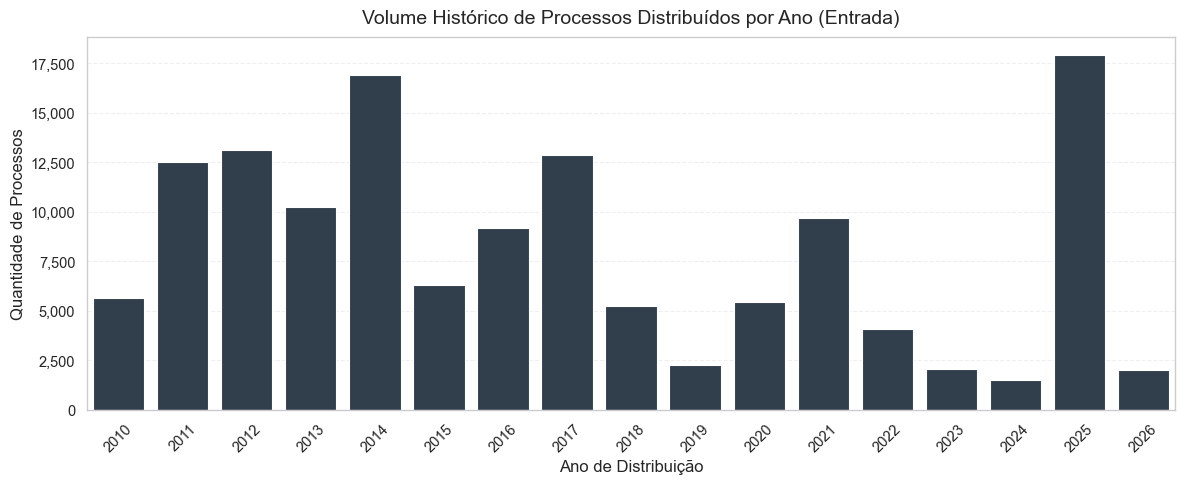

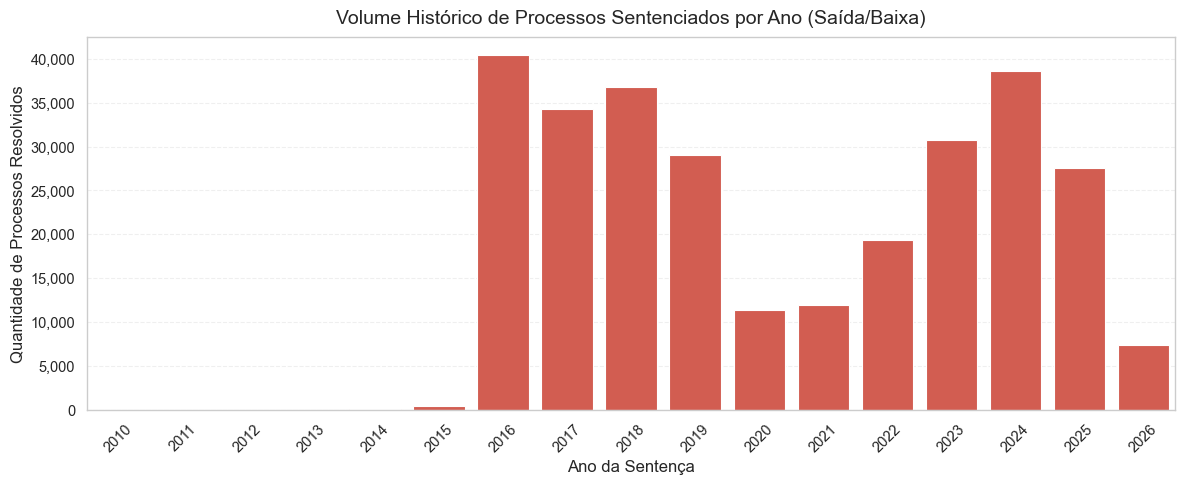

In [46]:
# 1. Extração do Ano de Sentença/Baixa usando a coluna correta (data_sentenca_clean)
if "ano_sentenca" not in df_pl.columns:
    df_pl = df_pl.with_columns(
        pl.col("data_sentenca_clean").cast(pl.Date).dt.year().alias("ano_sentenca")
    )

# 2. Agrupamento para Distribuição e Sentença (limitando aos últimos anos para o gráfico ficar legível)
df_dist_bar = df_pl.filter(
    (pl.col("ano_distribuicao") >= 2010) & (pl.col("ano_distribuicao") <= ano_atual)
).group_by("ano_distribuicao").len().sort("ano_distribuicao").to_pandas()

# Filtrando também os nulos para evitar que processos sem sentença caiam no gráfico
df_ext_bar = df_pl.filter(
    (pl.col("ano_sentenca").is_not_null()) &
    (pl.col("ano_sentenca") >= 2010) & (pl.col("ano_sentenca") <= ano_atual)
).group_by("ano_sentenca").len().sort("ano_sentenca").to_pandas()

# 3. Plotagem das Barras: Distribuição (Entrada)
plt.figure(figsize=(12, 5))
ax1 = sns.barplot(data=df_dist_bar, x="ano_distribuicao", y="len", color="#2c3e50")
plt.title("Volume Histórico de Processos Distribuídos por Ano (Entrada)", pad=10)
plt.xlabel("Ano de Distribuição")
plt.ylabel("Quantidade de Processos")
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
show_and_save("concentracao_foro_vara_valor")
plt.show()

# 4. Plotagem das Barras: Extinção/Sentença (Saída)
plt.figure(figsize=(12, 5))
ax2 = sns.barplot(data=df_ext_bar, x="ano_sentenca", y="len", color="#e74c3c") # Tom vermelho para "baixa"
plt.title("Volume Histórico de Processos Sentenciados por Ano (Saída/Baixa)", pad=10)
plt.xlabel("Ano da Sentença")
plt.ylabel("Quantidade de Processos Resolvidos")
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
show_and_save("concentracao_foro_vara_valor")
plt.show()

### 3.1.4. Concentração Estrutural: Top Foros e Varas por Volume Processual
Além da análise longitudinal, é fundamental compreender o mapa de calor estrutural do acervo. Os gráficos abaixo isolam as 10 unidades jurisdicionais (Foros) e os 10 órgãos julgadores (Varas/Setores) que concentram a maior carga de trabalho volumétrica (quantidade bruta de processos). Essa visão permite identificar gargalos físicos e direcionar alocação estratégica de procuradores.

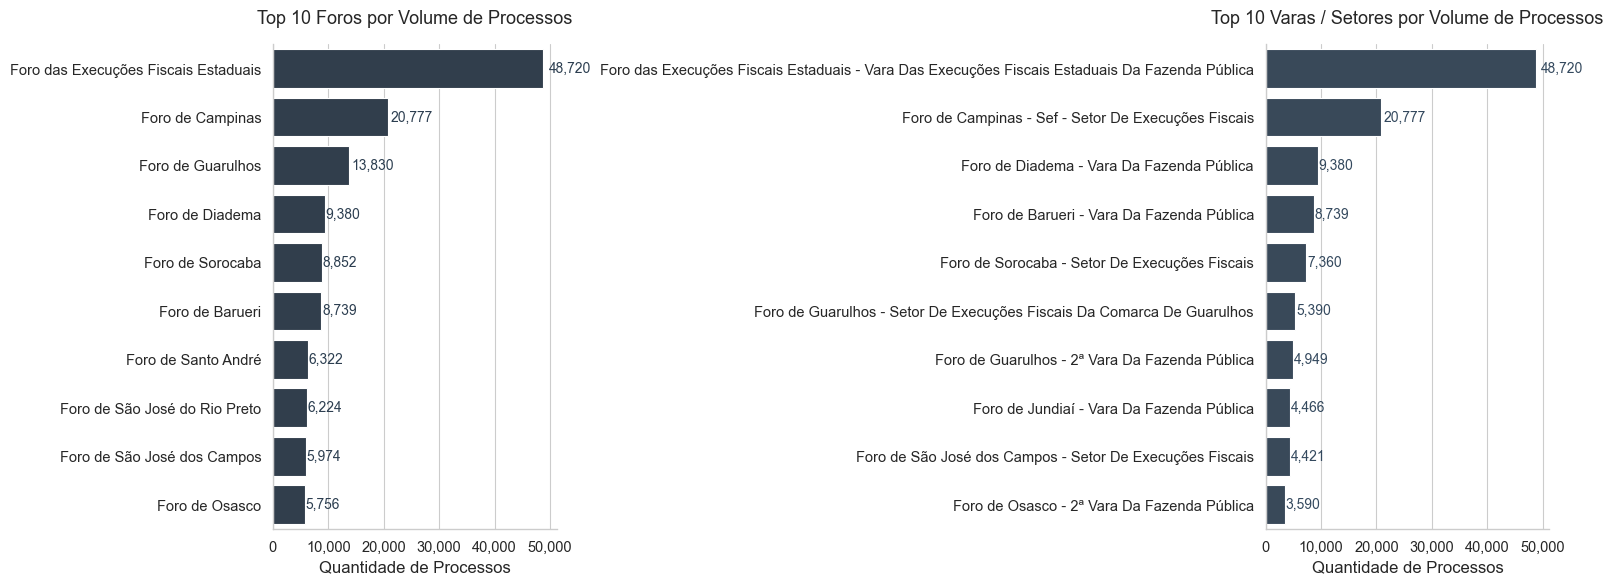

In [47]:
# 1. Agregações de Volume no Polars (Top 10)
df_foro_vol = df_pl.group_by("foro").len().sort("len", descending=True).head(10).to_pandas()

# Aqui usamos a nossa coluna "vara_limpa" que criamos lá na Seção 2!
df_vara_vol = df_pl.group_by("vara_limpa").len().sort("len", descending=True).head(10).to_pandas()

# 2. Configuração do Gráfico (Lado a Lado / Subplots)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- GRÁFICO A: FOROS ---
sns.barplot(data=df_foro_vol, y="foro", x="len", ax=axes[0], color="#2c3e50")
axes[0].set_title("Top 10 Foros por Volume de Processos", pad=15, fontsize=13)
axes[0].set_xlabel("Quantidade de Processos")
axes[0].set_ylabel("")
axes[0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))

# Adiciona os rótulos numéricos no final de cada barra
for i, v in enumerate(df_foro_vol["len"]):
    axes[0].text(v + (v * 0.02), i, f"{v:,.0f}", va='center', fontsize=10, color="#2c3e50")

# --- GRÁFICO B: VARAS LIMPAS ---
sns.barplot(data=df_vara_vol, y="vara_limpa", x="len", ax=axes[1], color="#34495e")
axes[1].set_title("Top 10 Varas / Setores por Volume de Processos", pad=15, fontsize=13)
axes[1].set_xlabel("Quantidade de Processos")
axes[1].set_ylabel("")
axes[1].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))

for i, v in enumerate(df_vara_vol["len"]):
    axes[1].text(v + (v * 0.02), i, f"{v:,.0f}", va='center', fontsize=10, color="#34495e")

# Ajustes finais para não cortar os nomes longos das varas
sns.despine()
plt.tight_layout()
show_and_save("dispersao_financeira")
plt.show()

### 3.1.4. Mapa de Risco Financeiro: Concentração de Valor por Foro e Vara
A volumetria de processos nem sempre guarda correlação direta com o risco financeiro. Um Foro pode ter poucos processos, mas concentrar execuções de altíssima monta (ex: grandes polos industriais e sedes corporativas). 

Os gráficos abaixo demonstram o **Valor Total Corrigido em Disputa (R$)** consolidado por unidade e órgão julgador. Identificar onde estão concentradas as maiores cifras (o "Risco-Fazenda") é vital para a criação de núcleos especializados de atuação estratégica.

*(Nota Metodológica: Para garantir que o mapa reflita o risco fiscal **real e recuperável**, o cálculo aplica duas travas de segurança jurimétricas:* *1. **Corte de Safra (Vintage Cut):** Filtro limitando a análise a processos distribuídos a partir dos anos 2000. Isso exclui o "passivo podre" de massas falidas da década de 90 (onde o Efeito Bola de Neve dos juros compostos por mais de 30 anos distorce a carteira com dívidas impagáveis de centenas de milhões).* *2. **Teto de Sanidade:** Exclusão de processos individuais com valor de causa superior a R$ 10 Bilhões, expurgando anomalias sistêmicas ou erros de digitação cometidos pelos cartórios de origem).*

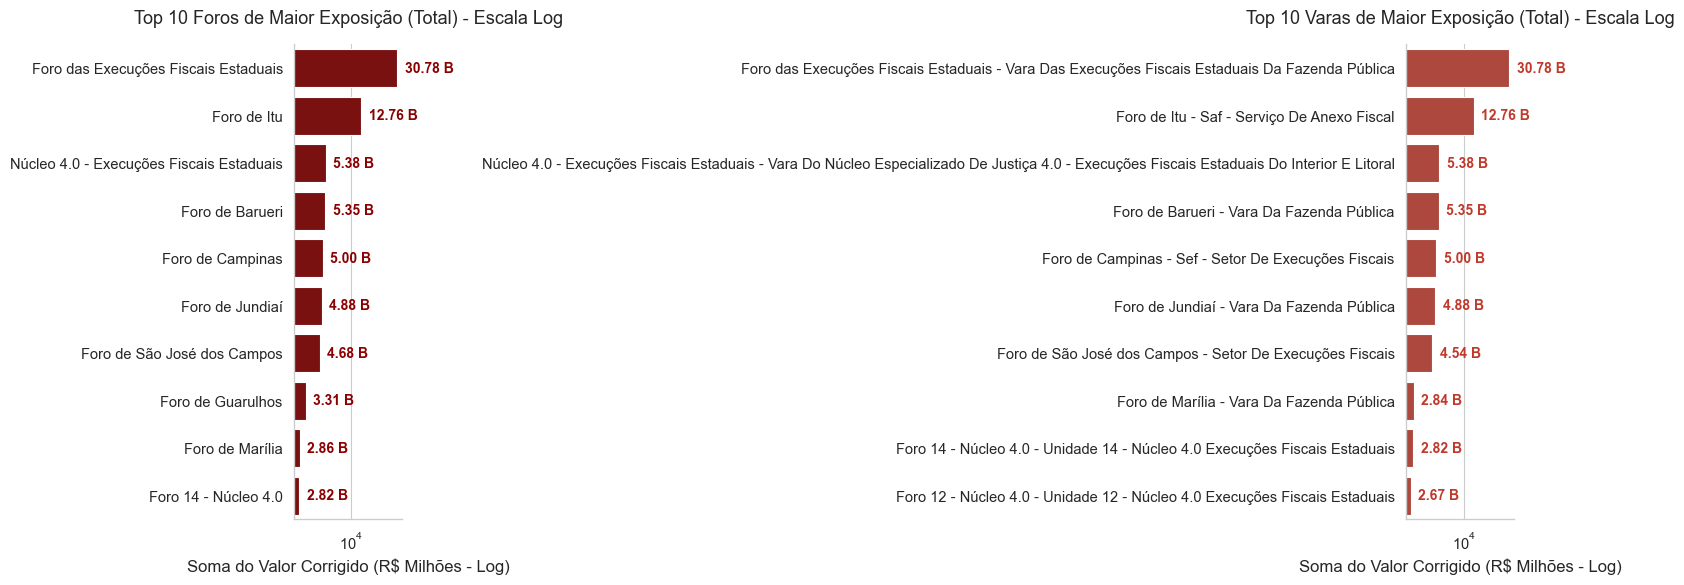

In [48]:
# Teto de Sanidade e Corte de Safra (Focando na dívida "cobrável" e mais recente)
teto_sanidade = 10_000_000_000 
ano_corte = 2000 # Ignoramos as "Massas Falidas" e Zumbis dos anos 90

# 1. Agregações Financeiras no Polars 
df_foro_val = df_pl.filter(
    (pl.col("valor_corrigido_atual").is_not_null()) &
    (pl.col("valor_corrigido_atual") <= teto_sanidade) &
    (pl.col("ano_distribuicao") >= ano_corte) # <--- O EXTERMINADOR DE ZUMBIS AQUI
).group_by("foro") \
 .agg(pl.col("valor_corrigido_atual").sum().alias("total_valor")) \
 .sort("total_valor", descending=True).head(10).to_pandas()

df_vara_val = df_pl.filter(
    (pl.col("valor_corrigido_atual").is_not_null()) &
    (pl.col("valor_corrigido_atual") <= teto_sanidade) &
    (pl.col("ano_distribuicao") >= ano_corte) # <--- E AQUI TAMBÉM
).group_by("vara_limpa") \
 .agg(pl.col("valor_corrigido_atual").sum().alias("total_valor")) \
 .sort("total_valor", descending=True).head(10).to_pandas()

# O resto do código (divisão por milhão e gráficos) continua idêntico...

# Convertendo para Milhões
df_foro_val["total_valor_mi"] = df_foro_val["total_valor"] / 1_000_000
df_vara_val["total_valor_mi"] = df_vara_val["total_valor"] / 1_000_000

# 2. Configuração do Gráfico (Lado a Lado)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- GRÁFICO A: VALOR POR FORO ---
sns.barplot(data=df_foro_val, y="foro", x="total_valor_mi", ax=axes[0], color="#8b0000")
axes[0].set_title("Top 10 Foros de Maior Exposição (Total) - Escala Log", pad=15, fontsize=13)
axes[0].set_xlabel("Soma do Valor Corrigido (R$ Milhões - Log)")
axes[0].set_ylabel("")
axes[0].set_xscale("log")

# Adiciona rótulos com conversão inteligente para Bilhões (B) ou Milhões (M)
for i, v in enumerate(df_foro_val["total_valor_mi"]):
    texto_rótulo = f"{v/1000:,.2f} B" if v >= 1000 else f"{v:,.0f} M"
    axes[0].text(v * 1.2, i, texto_rótulo, va='center', fontsize=10, color="#8b0000", fontweight='bold')

# --- GRÁFICO B: VALOR POR VARA ---
sns.barplot(data=df_vara_val, y="vara_limpa", x="total_valor_mi", ax=axes[1], color="#c0392b")
axes[1].set_title("Top 10 Varas de Maior Exposição (Total) - Escala Log", pad=15, fontsize=13)
axes[1].set_xlabel("Soma do Valor Corrigido (R$ Milhões - Log)")
axes[1].set_ylabel("")
axes[1].set_xscale("log")

for i, v in enumerate(df_vara_val["total_valor_mi"]):
    texto_rótulo = f"{v/1000:,.2f} B" if v >= 1000 else f"{v:,.0f} M"
    axes[1].text(v * 1.2, i, texto_rótulo, va='center', fontsize=10, color="#c0392b", fontweight='bold')

sns.despine()
plt.tight_layout()
show_and_save("carga_economica_ano")
plt.show()

### 3.2. Dispersão Financeira e Volumetria Econômica
A análise da carga econômica do acervo exige cautela metodológica. Bases do Judiciário contêm anomalias severas, como erros de digitação em cartórios (ex: processos com valores irreais na casa dos trilhões) e "processos zumbis" (execuções antigas cujo efeito de juros compostos por décadas gerou montantes impagáveis).

*(Nota Metodológica Universal: Para garantir que os indicadores reflitam o risco financeiro real, todas as análises de valor corrigido nesta seção aplicam um **Teto de Sanidade**, excluindo sumariamente qualquer processo individual cujo valor supere **R$ 1 Bilhão**. Adicionalmente, na análise de Ticket Médio, aplica-se o corte do **Percentil 95 (P95)** para isolar os 5% de processos mais extremos e revelar o comportamento da grande massa do acervo).*

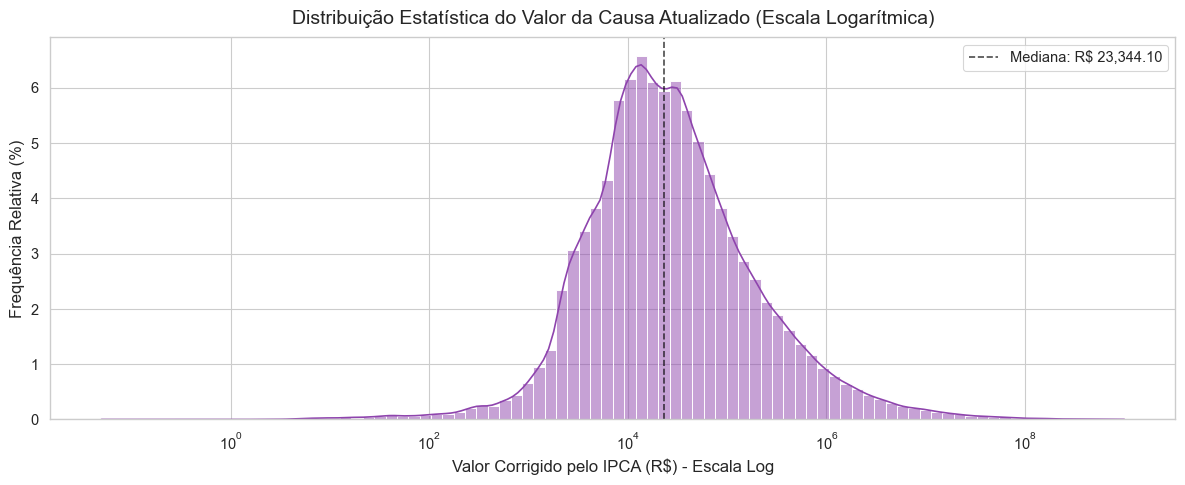

In [49]:
# Teto de sanidade global para remover erros crassos de cartório
teto_sanidade = 1_000_000_000 

# Extrai array numpy direto do Polars para plotting (com o teto aplicado)
array_valores = df_pl.filter(
    (pl.col("valor_corrigido_atual").is_not_null()) & 
    (pl.col("valor_corrigido_atual") > 0) &
    (pl.col("valor_corrigido_atual") <= teto_sanidade) # <--- AQUI: Filtro do teto
).select("valor_corrigido_atual").to_series().to_numpy()

plt.figure(figsize=(12, 5))
# KDE e Histograma na escala Log
sns.histplot(array_valores, bins=90, log_scale=True, color="#8e44ad", kde=True, stat="percent")

plt.title("Distribuição Estatística do Valor da Causa Atualizado (Escala Logarítmica)", pad=10)
plt.xlabel("Valor Corrigido pelo IPCA (R$) - Escala Log")
plt.ylabel("Frequência Relativa (%)")

# Linha da Mediana
mediana_val = np.median(array_valores)
plt.axvline(mediana_val, color='black', linestyle='--', alpha=0.7, label=f"Mediana: R$ {mediana_val:,.2f}")
plt.legend()
plt.tight_layout()
show_and_save("ticket_medio_ano")
plt.show()

### 3.2.1. Carga Econômica Ajuizada por Ano (Evolução da Massa Processual)
Acompanhamento da série histórica do montante econômico em disputa. Esta visão revela o peso financeiro agregado das demandas ingressadas a cada ano, isolando a "massa padrão" de processos do Estado.

*(Notas Metodológicas: **1.** Para evitar que redistribuições de mega-execuções antigas distorçam a tendência de um único ano, aplicou-se o corte de **Percentil 999 (P999)**, excluindo o 0.1% de processos com valores mais extremos. **2.** O ano de **2026** apresenta uma queda natural na soma por se tratar de um exercício fiscal em curso (dados parciais até abril/2026).*

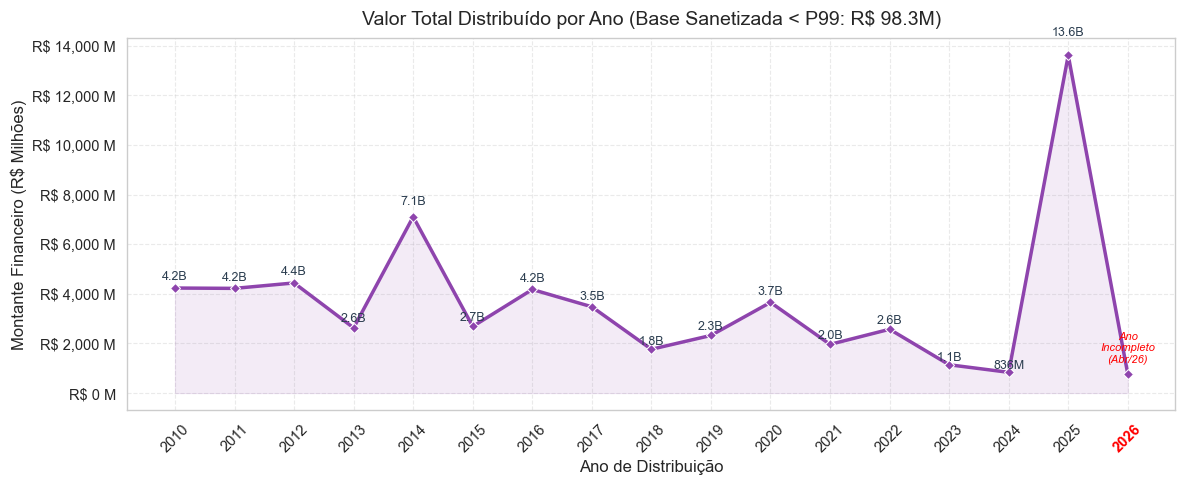

In [50]:
# 0. Calcula o P999 para limpar o 0.1% das mega-execuções (que distorceram 2025)
limite_p99 = df_pl.select(
    pl.col("valor_corrigido_atual").drop_nulls().quantile(0.999)
).item()

# 1. Agrupamento no Polars (COM CORTE DO P99)
df_valor_ano = df_pl.filter(
    (pl.col("ano_distribuicao") >= 2010) & 
    (pl.col("ano_distribuicao") <= ano_atual) &
    (pl.col("valor_corrigido_atual").is_not_null()) &
    (pl.col("valor_corrigido_atual") <= limite_p99) # <--- O Exterminador da anomalia de 2025
).group_by("ano_distribuicao").agg(
    pl.col("valor_corrigido_atual").sum().alias("valor_total")
).sort("ano_distribuicao").to_pandas()

# 2. Transformação para Milhões (R$)
df_valor_ano["valor_total_mi"] = df_valor_ano["valor_total"] / 1_000_000

# 3. Plotagem em Linha
plt.figure(figsize=(12, 5))
ax = sns.lineplot(
    data=df_valor_ano, 
    x="ano_distribuicao", 
    y="valor_total_mi", 
    marker="D", 
    color="#8e44ad", 
    linewidth=2.5
)

plt.title(f"Valor Total Distribuído por Ano (Base Sanetizada < P99: R$ {limite_p99/1_000_000:,.1f}M)", pad=10)
plt.xlabel("Ano de Distribuição")
plt.ylabel("Montante Financeiro (R$ Milhões)")

# 4. Ajustes visuais
plt.fill_between(df_valor_ano["ano_distribuicao"], df_valor_ano["valor_total_mi"], alpha=0.1, color="#8e44ad")
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'R$ {x:,.0f} M'))

# Destaca 2026 com uma cor diferente no eixo X para alertar que é ano incompleto
plt.xticks(df_valor_ano["ano_distribuicao"].to_list(), rotation=45)
ax.get_xticklabels()[-1].set_color("red") 
ax.get_xticklabels()[-1].set_fontweight("bold")

plt.grid(True, linestyle='--', alpha=0.4)

# 5. Adiciona os rótulos (Oculta o rótulo de 2026 para não poluir, já que é parcial)
for i, row in df_valor_ano.iterrows():
    val = row['valor_total_mi']
    ano = row['ano_distribuicao']
    if val > 0 and ano != 2026:
        texto = f"{val/1000:.1f}B" if val >= 1000 else f"{val:.0f}M"
        plt.text(ano, val * 1.05, texto, ha='center', va='bottom', fontsize=9, color="#2c3e50")

# Alerta no gráfico sobre 2026
plt.text(2026, df_valor_ano.iloc[-1]['valor_total_mi'] * 1.5, "Ano\nIncompleto\n(Abr/26)", 
         ha='center', va='bottom', color="red", fontsize=8, style='italic')

plt.tight_layout()
show_and_save("eficiencia_tempo_sentenca")
plt.show()

#### Detalhamento do Extremo: A Mega-Execução de Cada Ano (Top 1)
A tabela a seguir isola **a única demanda de maior impacto econômico** ajuizada em cada exercício (Top 1). 

*(Nota Metodológica: Diferente da curva de Ticket Médio, **um corte estatístico (P9999) é aplicado nesta tabela**. O objetivo aqui é justamente identificar os *outliers* quase absolutos — as execuções fiscais milionárias ou bilionárias e seus respectivos polos passivos que causam as maiores anomalias na série histórica do Estado).*

In [51]:
# 0. Calcula o limite do P9999 (Percentil 9999) para isolar o 0,01% de valores anômalos/erros
quantile = 0.9999
limite_p = df_pl.select(
    pl.col("valor_corrigido_atual").drop_nulls().quantile(quantile)
).item()

# 1. Engenharia de Features: Juntando o Réu e o Advogado em uma única string amigável
df_temp = df_pl.with_columns([
    pl.concat_str([
        pl.col("reus").fill_null("Não informado"),
        pl.lit(" (Adv: "),
        pl.col("advogados_reus").fill_null("Não informado"),
        pl.lit(")")
    ]).alias("reu_e_advogado")
])

# 2. Definimos as colunas atualizadas que queremos visualizar
colunas_capa = [
    "ano_distribuicao", 
    "numero", 
    "foro", 
    "classe", 
    "reu_e_advogado",
    "valor_corrigido_atual"
]

# 3. Lógica no Polars: Filtrar P9999 -> Ordenar por Ano e Valor -> Pegar o PRIMEIRO de cada grupo
df_top1_ano = df_temp.filter(
    (pl.col("ano_distribuicao") >= 2010) & 
    (pl.col("ano_distribuicao") <= ano_atual) &
    (pl.col("valor_corrigido_atual").is_not_null()) &
    (pl.col("valor_corrigido_atual") <= limite_p)  
).sort(
    ["ano_distribuicao", "valor_corrigido_atual"], descending=[False, True]
).group_by(
    "ano_distribuicao", maintain_order=True
).first().select(colunas_capa)

# 4. Tratamento visual refinado usando Pandas Styling
df_top1_pandas = df_top1_ano.to_pandas()

# Renomeando as colunas para o "front-end" ficar legível para a MP
df_top1_pandas.columns = ["Ano", "Processo", "Foro", "Classe", "Polo Passivo (Réu e Adv.)", "Valor Atualizado"]

# Aplicando CSS/Estilo do Pandas para melhorar a apresentação
estilo_tabela = (
    df_top1_pandas.style
    .format({"Valor Atualizado": "R$ {:,.2f}"})
    .hide(axis="index") # Remove a coluna de índices
    .set_properties(**{'text-align': 'left'})
    .set_properties(subset=['Valor Atualizado', 'Ano'], **{'text-align': 'center'})
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('text-align', 'center')]}
    ])
)

print("="*100)
# Adicionei o valor exato do P99 no título para documentar o corte metodológico para a chefia!
print(f" 🏆 O MAIOR PROCESSO DE CADA ANO (Excluindo o Top {quantile*100}% > R$ {limite_p:,.2f})")
print("="*100)

# Renderiza a tabela formatada
display(estilo_tabela)

 🏆 O MAIOR PROCESSO DE CADA ANO (Excluindo o Top 99.99% > R$ 1,403,753,746.59)


Ano,Processo,Foro,Classe,Polo Passivo (Réu e Adv.),Valor Atualizado
2010,0003007-81.2010.8.26.0185,Foro de Estrela D'Oeste,Execução Fiscal,"Frigoestrela Frigorífico Estrela D´oeste Ltda (Adv: Marcelo Guaritá Borges Bento, Adirson de Oliveira Beber Junior)","R$ 300,716,459.06"
2011,0018735-29.2005.8.26.0286,Foro de Cabreúva,Execução Fiscal,Altecan Tintas e Vernizes Ltda (Adv: Ademar Fernandes de Oliveira),"R$ 1,021,255,018.81"
2012,0204691-17.2012.8.26.0014,Foro das Execuções Fiscais Estaduais,Execução Fiscal,Realeza Coml e Distrib de Bebidas Ltda (Adv: Réu Revel),"R$ 684,963,266.94"
2013,0002774-82.2011.8.26.0045,Foro de Arujá,Execução Fiscal,Nova União Industria e Comercio de Papéis Ltda (Adv: NÃO HÁ REGISTRO),"R$ 217,707,961.95"
2014,1522586-27.2014.8.26.0014,Foro das Execuções Fiscais Estaduais,Execução Fiscal,"Distrib Automotiva Ltda (Adv: Daniella Zagari Goncalves, Marco Antônio Gomes Behrndt)","R$ 188,493,930.85"
2015,1500011-63.2015.8.26.0281,Foro de Itatiba,Execução Fiscal,"Beiersdorf Industria e Comercio Ltda. (Adv: Luciana Rosanova Galhardo, Diego Filipe Casseb)","R$ 409,632,508.79"
2016,1501084-61.2016.8.26.0014,Foro das Execuções Fiscais Estaduais,Execução Fiscal,Microsoft Informatica Ltda (Adv: Marcos de Carvalho),"R$ 606,283,160.45"
2017,0900343-36.1993.8.26.0577,Foro de São José dos Campos,Execução Fiscal,Artefatos Elet Mec Aeronautica Ltda (Adv: NÃO HÁ REGISTRO),"R$ 691,771,561.24"
2018,1500532-28.2018.8.26.0014,Foro das Execuções Fiscais Estaduais,Execução Fiscal,Comercial Mix 10 Eireli Epp (Adv: NÃO HÁ REGISTRO),"R$ 205,145,123.82"
2019,1502461-73.2019.8.26.0269,Foro de Itapetininga,Execução Fiscal,Acumuladores Moura S/A (Adv: Celso Luiz de Oliveira),"R$ 166,092,522.21"


### 3.2.2. Valor Médio da Causa por Ano de Distribuição (Ticket Médio)
Enquanto a soma revela o volume total, o **Ticket Médio** indica o perfil individual das demandas. Uma elevação constante alerta que os processos estão se tornando estruturalmente mais caros.

*(Notas Metodológicas: **1.** Como a média é altamente sensível a outliers, aplicou-se o rigoroso corte do **Percentil 95 (P95)**, isolando os 5% de processos mais extremos. Isso garante que a linha represente o custo real do processo típico enfrentado pela PGE. **2.** Os dados de 2026 refletem apenas o primeiro trimestre).*

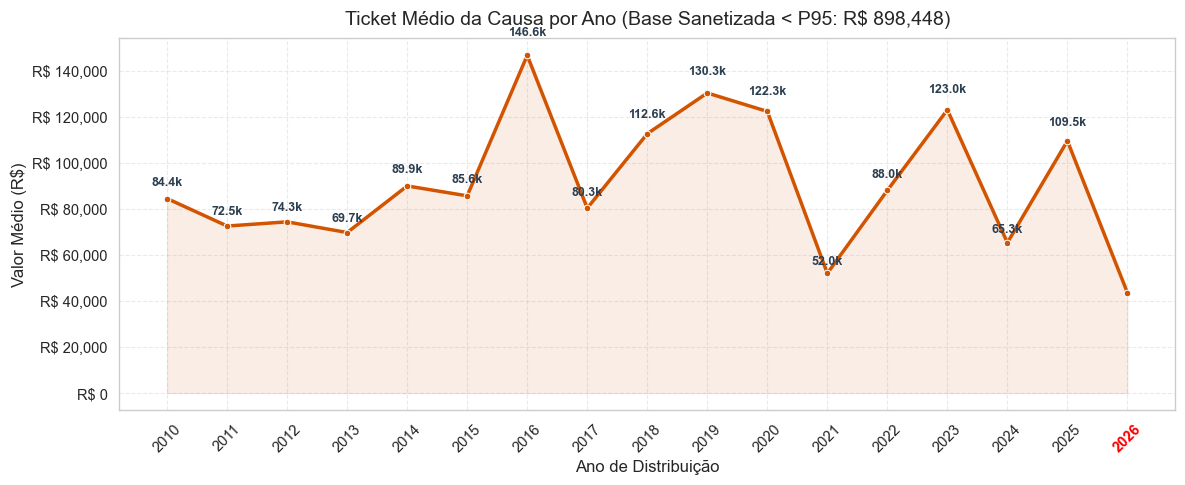

In [52]:
# 0. Calcula o limite do P95 para o Ticket Médio
limite_p95 = df_pl.select(
    pl.col("valor_corrigido_atual").drop_nulls().quantile(0.95)
).item()

# 1. Agrupamento no Polars (COM CORTE DO P95)
df_media_ano = df_pl.filter(
    (pl.col("ano_distribuicao") >= 2010) & 
    (pl.col("ano_distribuicao") <= ano_atual) &
    (pl.col("valor_corrigido_atual").is_not_null()) &
    (pl.col("valor_corrigido_atual") <= limite_p95)
).group_by("ano_distribuicao").agg(
    pl.col("valor_corrigido_atual").mean().alias("valor_medio")
).sort("ano_distribuicao").to_pandas()

# 2. Plotagem em Linha
plt.figure(figsize=(12, 5))
ax = sns.lineplot(
    data=df_media_ano, 
    x="ano_distribuicao", 
    y="valor_medio", 
    marker="o", 
    color="#d35400", 
    linewidth=2.5
)

plt.title(f"Ticket Médio da Causa por Ano (Base Sanetizada < P95: R$ {limite_p95:,.0f})", pad=10)
plt.xlabel("Ano de Distribuição")
plt.ylabel("Valor Médio (R$)")

# 3. Ajustes visuais
plt.fill_between(df_media_ano["ano_distribuicao"], df_media_ano["valor_medio"], alpha=0.1, color="#d35400")
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'R$ {x:,.0f}'))

plt.xticks(df_media_ano["ano_distribuicao"].to_list(), rotation=45)
ax.get_xticklabels()[-1].set_color("red") 
ax.get_xticklabels()[-1].set_fontweight("bold")

plt.grid(True, linestyle='--', alpha=0.4)

# 4. Adiciona os rótulos (Oculta o de 2026)
for i, row in df_media_ano.iterrows():
    val = row['valor_medio']
    ano = row['ano_distribuicao']
    if val > 0 and ano != 2026:
        texto_valor = f"{val/1000:.1f}k" if val >= 1000 else f"{val:.0f}"
        plt.text(ano, val * 1.05, texto_valor, ha='center', va='bottom', fontsize=9, color="#2c3e50", fontweight='bold')

plt.tight_layout()
show_and_save("mapa_risco_foros")
plt.show()

### 3.3. Eficiência Jurisdicional (Análise de Sobrevivência Básica)
Análise do decurso temporal entre o ajuizamento da lide e a consolidação de uma sentença judicial (resolução de mérito ou extinção processual).

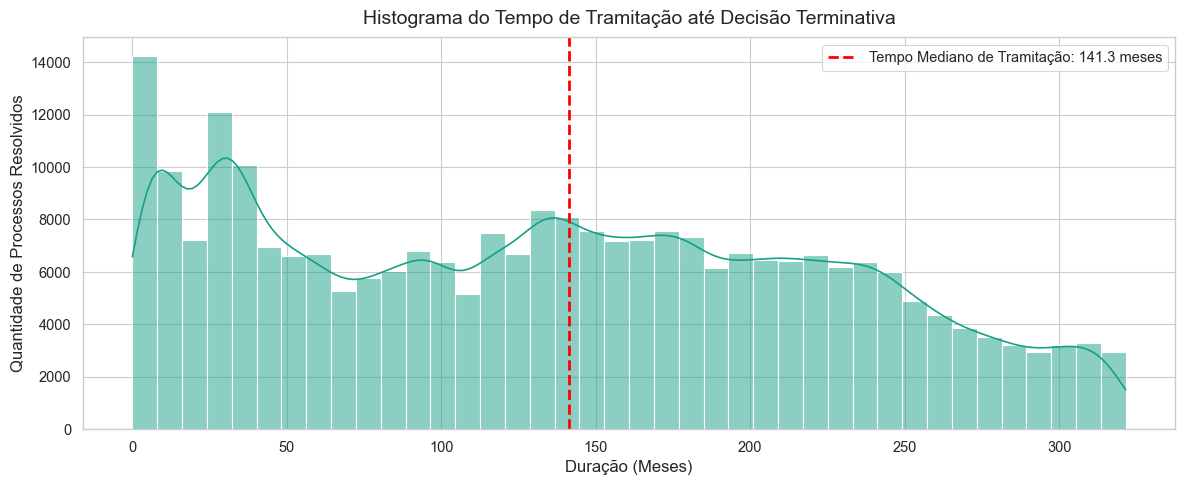

In [53]:
# Filtra tempos negativos (anomalias já diagnosticadas) e recorta o top 5% mais extremo 
# para permitir a visualização de tendência central.
tempo_serie = df_pl.filter(
    (pl.col("tempo_ate_sentenca_meses").is_not_null()) & 
    (pl.col("tempo_ate_sentenca_meses") > 0)
).select("tempo_ate_sentenca_meses").to_series()

if len(tempo_serie) > 0:
    limite_visual_tempo = tempo_serie.quantile(0.95)
    array_tempo = tempo_serie.filter(tempo_serie <= limite_visual_tempo).to_numpy()

    plt.figure(figsize=(12, 5))
    sns.histplot(array_tempo, bins=40, color="#16a085", kde=True)

    mediana_tempo = tempo_serie.median()
    plt.axvline(mediana_tempo, color='red', linestyle='dashed', linewidth=2, 
                label=f'Tempo Mediano de Tramitação: {mediana_tempo:.1f} meses')

    plt.title("Histograma do Tempo de Tramitação até Decisão Terminativa", pad=10)
    plt.xlabel("Duração (Meses)")
    plt.ylabel("Quantidade de Processos Resolvidos")
    plt.legend()
    plt.tight_layout()
    show_and_save("extra_plot")
    plt.show()
else:
    print("Dados insuficientes de tempo de tramitação para gerar o gráfico.")

In [54]:
# Exportação final da base filtrada (para reprodutibilidade)
# Obs.: a coluna `movimentações` é omitida para evitar estouro de RAM.
export_csv_path = ARTIFACTS_DIR / "fesp_execucao_fiscal_icms_assuntos_filtered.csv"

df_pl.write_csv(str(export_csv_path))
print(f"CSV exportado: {export_csv_path}")

CSV exportado: /Users/etorebraga/Code/habitual-tax-debtor-research/notebooks/articles/eped-2026-analise-execucoes-fiscais/artifacts/fesp_execucao_fiscal_icms_assuntos_filtered.csv
